In [1]:
import os
import glob

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline

## Carga de Recursos

In [15]:
dir = "resources/white_patch"

image_wp_paths = sorted(
    glob.glob(os.path.join(dir, "*.png")) +
    glob.glob(os.path.join(dir, "*.jpg")) +
    glob.glob(os.path.join(dir, "*.jpeg"))
)

print("Imágenes encontradas:")

for path in image_wp_paths:
    print(path)

Imágenes encontradas:
resources/white_patch\test_blue.png
resources/white_patch\test_green.png
resources/white_patch\test_red.png
resources/white_patch\wp_blue.jpg
resources/white_patch\wp_green.png
resources/white_patch\wp_green2.jpg
resources/white_patch\wp_red.png
resources/white_patch\wp_red2.jpg


## Funciones

In [9]:
def white_patch(image_bgr: np.ndarray) -> np.ndarray:
    """
    Aplica el algoritmo White Patch a una imagen BGR.
    """
    image_float = image_bgr.astype(np.float32)

    # máximos por canal (B,G,R)
    b_max, g_max, r_max = image_float.reshape(-1, 3).max(axis=0)

    # evitar división por cero
    if b_max == 0:
        b_max = 1
    if g_max == 0:
        g_max = 1
    if r_max == 0:
        r_max = 1

    corrected = image_float.copy()
    corrected[:, :, 0] = corrected[:, :, 0] * (255.0 / b_max)  # B
    corrected[:, :, 1] = corrected[:, :, 1] * (255.0 / g_max)  # G
    corrected[:, :, 2] = corrected[:, :, 2] * (255.0 / r_max)  # R

    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected

In [11]:
def show_white_patch_result(image_path: str) -> None:
    """
    Carga una imagen, aplica White Patch y muestra
    la imagen original junto con la corregida.
    """

    image_bgr = cv.imread(image_path)

    if image_bgr is None:
        print(f"No se pudo leer: {image_path}")
        return

    corrected_bgr = white_patch(image_bgr)

    # Matplotlib espera RGB, no BGR
    image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
    corrected_rgb = cv.cvtColor(corrected_bgr, cv.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(image_rgb)
    axes[0].set_title("Imagen original")
    axes[0].axis("off")

    axes[1].imshow(corrected_rgb)
    axes[1].set_title("Corrección White Patch")
    axes[1].axis("off")

    fig.suptitle(os.path.basename(image_path))
    plt.tight_layout()
    plt.show()

In [12]:
def white_patch_info(image_bgr: np.ndarray) -> dict:
    """
    Devuelve máximos y ganancias utilizadas por White Patch.
    """

    image_float = image_bgr.astype(np.float32)
    b_max, g_max, r_max = image_float.reshape(-1, 3).max(axis=0)

    gains = np.array([
        255.0 / b_max if b_max > 0 else 0,
        255.0 / g_max if g_max > 0 else 0,
        255.0 / r_max if r_max > 0 else 0
    ])

    return {
        "B_max": b_max,
        "G_max": g_max,
        "R_max": r_max,
        "B_gain": gains[0],
        "G_gain": gains[1],
        "R_gain": gains[2]
    }

# Parte 1

## Ejecución

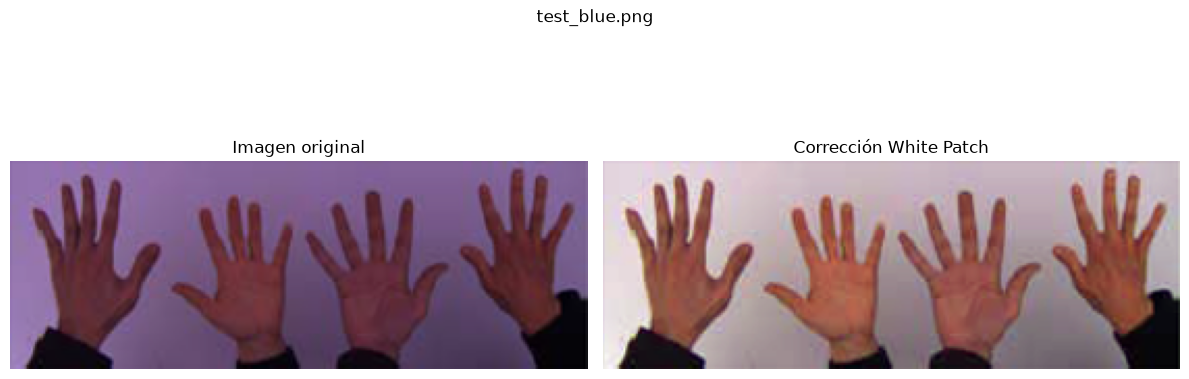

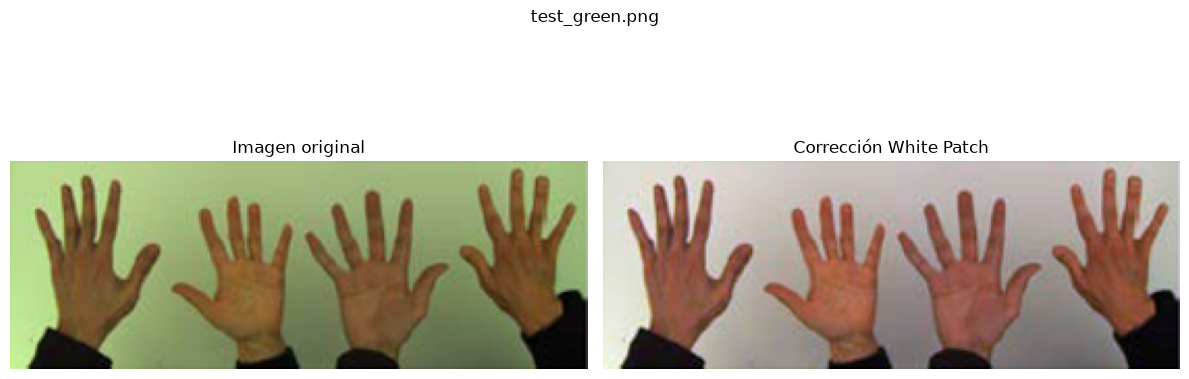

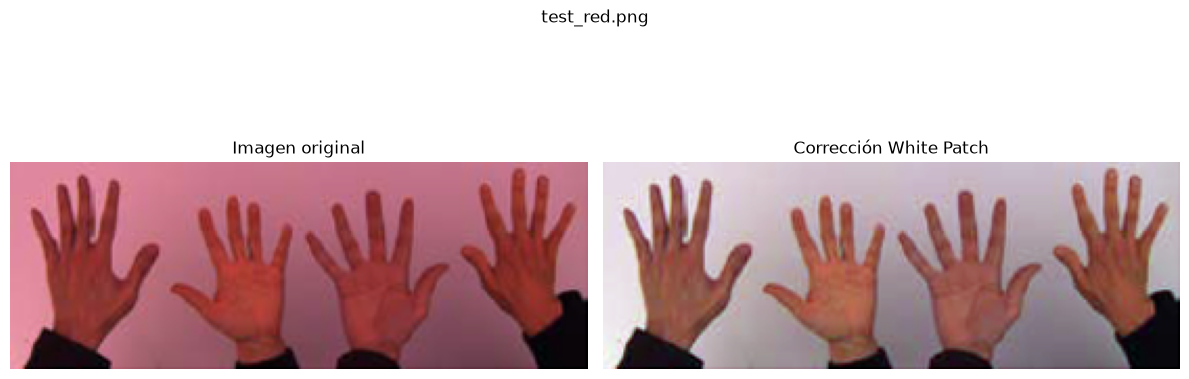

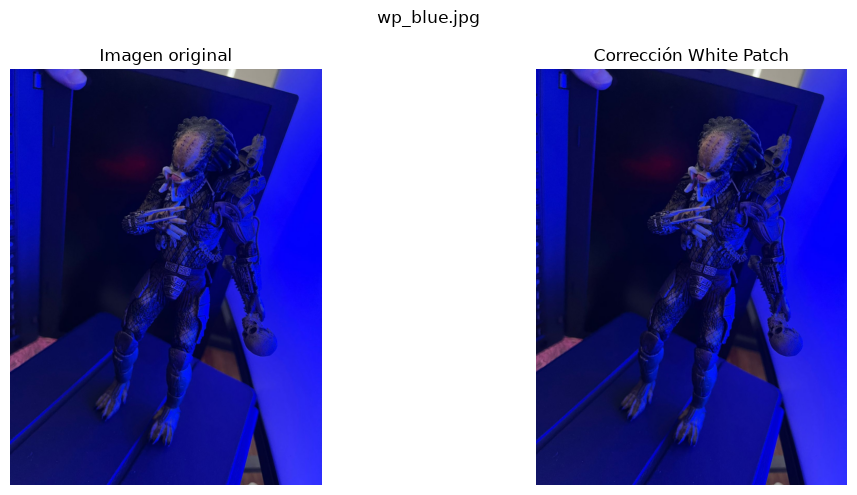

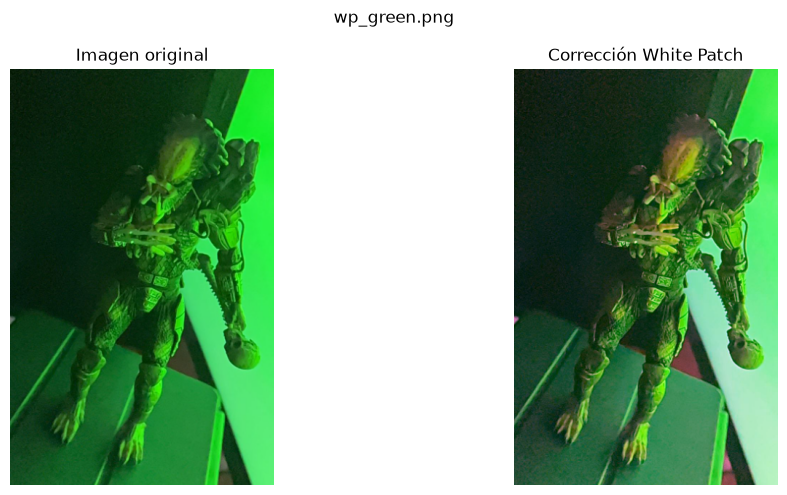

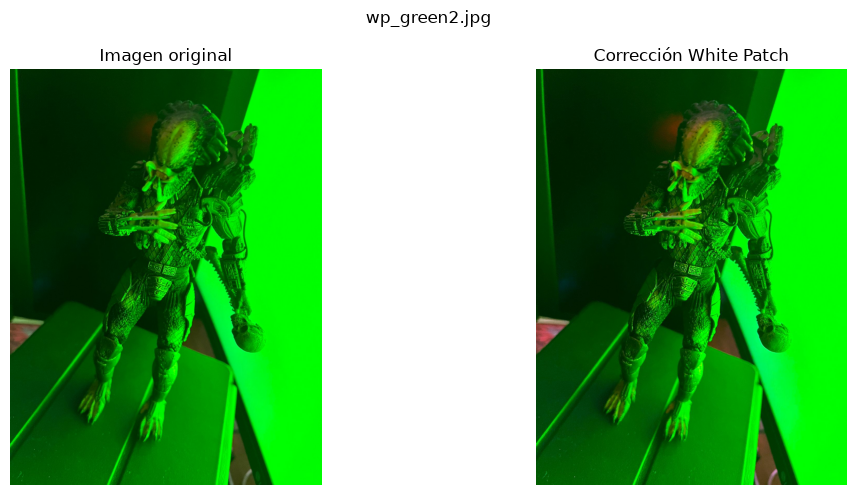

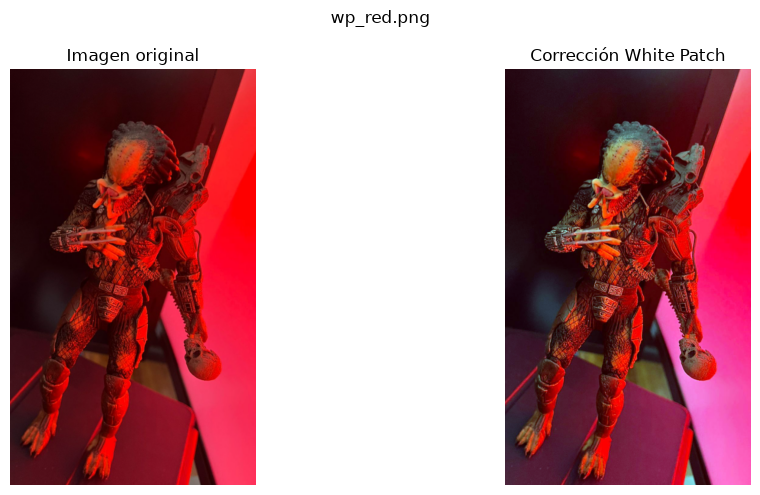

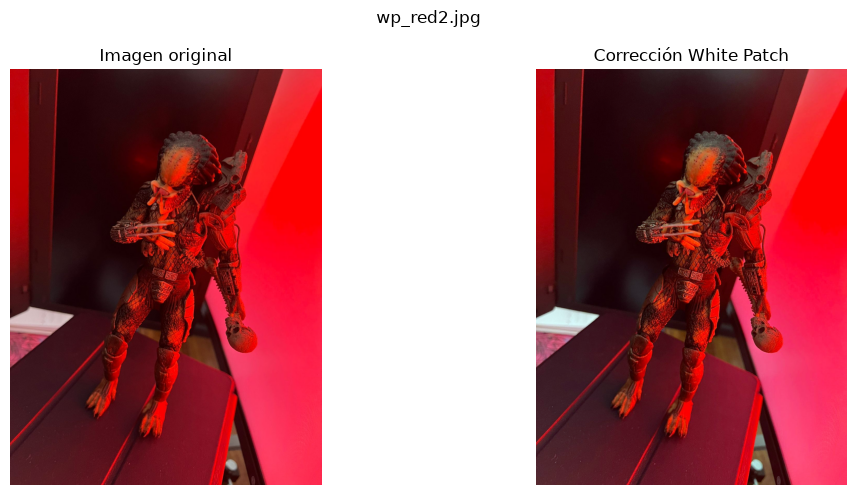

In [18]:
for path in image_wp_paths:
    show_white_patch_result(path)

In [19]:
import pandas as pd

results = []

for path in image_wp_paths:
    img = cv.imread(path)

    if img is None:
        continue

    info = white_patch_info(img)

    results.append({
        "imagen": os.path.basename(path),
        "B_max": info["B_max"],
        "G_max": info["G_max"],
        "R_max": info["R_max"],
        "B_gain": info["B_gain"],
        "G_gain": info["G_gain"],
        "R_gain": info["R_gain"]
    })

df_white_patch = pd.DataFrame(results)
df_white_patch.round(3)

,imagen,B_max,G_max,R_max,B_gain,G_gain,R_gain
0,test_blue.png,200.0,138.0,165.0,1.275,1.848,1.545
1,test_green.png,171.0,250.0,210.0,1.491,1.020,1.214
2,test_red.png,175.0,157.0,247.0,1.457,1.624,1.032
3,wp_blue.jpg,255.0,255.0,255.0,1.000,1.000,1.000
4,wp_green.png,155.0,252.0,126.0,1.645,1.012,2.024
5,wp_green2.jpg,172.0,255.0,170.0,1.483,1.000,1.500
6,wp_red.png,122.0,134.0,255.0,2.090,1.903,1.000
7,wp_red2.jpg,203.0,201.0,255.0,1.256,1.269,1.000


El análisis de los valores máximos y de las ganancias calculadas permite explicar mejor los resultados visuales. En las imágenes `test_blue.png`, `test_green.png` y `test_red.png`, los canales asociados a la dominante de color reciben ganancias cercanas a 1, mientras que los otros canales se amplifican en mayor medida. Esto permite compensar el desequilibrio entre canales y recuperar colores más naturales.

El caso de `wp_blue.jpg` resulta especialmente representativo de una falla del método. Los tres canales presentan un valor máximo de 255, por lo que las ganancias calculadas son exactamente iguales a 1. Como consecuencia, la imagen no se modifica, aunque visualmente mantiene una fuerte dominante azul. Esto ocurre porque White Patch solo considera los valores máximos de cada canal y no verifica si esos máximos pertenecen a una misma región blanca o neutra.

En `wp_green.png` y `wp_red.png` se observan diferencias importantes entre las ganancias de los canales. En ambos casos, los canales menos intensos son amplificados de forma considerable, lo que produce una corrección más visible. Por ejemplo, en `wp_red.png` los canales azul y verde reciben ganancias cercanas a 2, mientras que el canal rojo permanece sin cambios. Esto reduce la dominante roja y permite recuperar colores que originalmente se encontraban ocultos.

Por otro lado, en `wp_green2.jpg` y `wp_red2.jpg` las ganancias indican que existe cierta compensación entre canales, pero el resultado visual sigue siendo limitado. Esto demuestra que el comportamiento del algoritmo no depende solamente de los valores máximos, sino también de la distribución de intensidades, la saturación y la uniformidad de la iluminación.

## Análisis de resultados, posibles fallas y conclusiones

La aplicación del algoritmo White Patch permitió observar comportamientos distintos según el tipo de imagen y las condiciones de iluminación presentes en cada caso.

En las imágenes `test_blue.png`, `test_green.png` y `test_red.png`, la corrección fue satisfactoria. Las imágenes originales presentan una dominante azul, verde o roja que modifica tanto el fondo como el color de las manos. Luego de aplicar White Patch, el fondo adquiere un tono mucho más cercano al gris o al blanco, mientras que los tonos de piel se ven más naturales y similares entre sí. Esto muestra que, en estas imágenes, los valores máximos de los canales rojo, verde y azul funcionan razonablemente bien como referencia del blanco de la escena.

En las imágenes del muñeco, en cambio, los resultados fueron menos uniformes. En `wp_red.png` se observa una mejora clara: la dominante roja disminuye y aparecen con mayor detalle colores del muñeco que antes quedaban ocultos por la iluminación. También se recuperan mejor algunas zonas con tonos verdes, azules y grises. En `wp_green.png` la corrección es visible, aunque la imagen conserva una componente verde importante. Esto indica que el algoritmo logra compensar parcialmente la iluminación, pero no alcanza a neutralizarla por completo.

Por otro lado, en `wp_blue.jpg`, `wp_green2.jpg` y `wp_red2.jpg` la diferencia entre la imagen original y la corregida es mucho menor. En estos casos, la dominante de color permanece en gran parte de la escena. Esto no significa necesariamente que la implementación sea incorrecta, sino que la hipótesis en la que se basa White Patch no se cumple adecuadamente para esas imágenes.

El algoritmo supone que los valores máximos de cada canal corresponden a una superficie blanca iluminada por la fuente de luz de la escena. A partir de esa referencia, cada canal se escala de forma independiente para llevar su máximo a 255. El problema es que, en una imagen real, los máximos de rojo, verde y azul pueden pertenecer a zonas diferentes. Por ejemplo, el máximo del canal rojo puede estar en una superficie iluminada directamente, mientras que el máximo del canal azul puede aparecer en un reflejo o en otro objeto. En ese caso, el algoritmo construye una referencia de blanco a partir de valores que no representan una misma región física.

Otra posible falla aparece cuando no existe un objeto blanco o neutro dentro de la escena. En varias imágenes del muñeco, gran parte del encuadre está dominada por una iluminación de color intensa. El píxel más brillante puede corresponder a una pared verde, a una superficie roja o a un reflejo azul, y no a una referencia blanca. Como consecuencia, la corrección puede mantener parte de la dominante original o incluso alterar algunos colores reales del objeto.

También debe considerarse la saturación. Si un canal ya alcanza el valor 255, la información por encima de ese límite se pierde. El algoritmo solo sabe que el canal llegó al máximo permitido, pero no puede determinar cuál era su intensidad real antes de la saturación. En esos casos, la estimación de la ganancia deja de ser confiable. Además, si los tres canales tienen algún valor cercano a 255 en distintas zonas de la imagen, las ganancias calculadas resultan cercanas a 1 y la corrección final puede ser muy pequeña, aunque visualmente la escena siga presentando una dominante marcada.

Otro límite importante es que White Patch aplica una corrección global. Se calcula una única ganancia para cada canal y se aplica a todos los píxeles de la imagen. Por lo tanto, no puede corregir adecuadamente escenas con iluminación no uniforme, sombras de distinto color o varias fuentes de luz. Si una parte de la imagen está iluminada con luz roja y otra con luz neutra, una única transformación no puede compensar ambas regiones al mismo tiempo.

Los resultados también muestran que dos imágenes con una dominante similar pueden responder de manera diferente. Esto se observa, por ejemplo, al comparar `wp_red.png` con `wp_red2.jpg`. En la primera, la corrección es bastante evidente, mientras que en la segunda el efecto es más limitado. Esto indica que el desempeño del algoritmo no depende únicamente del color predominante, sino también de la distribución de intensidades, la presencia de zonas claras, el nivel de saturación y la composición general de la escena.

En conclusión, White Patch es un método simple, rápido y de bajo costo computacional que puede resultar efectivo cuando la imagen contiene una región clara y aproximadamente neutra, la iluminación es relativamente uniforme y no existen saturaciones importantes. Las imágenes de prueba de las manos muestran un caso favorable, ya que la dominante de color se reduce de forma clara y el fondo se vuelve más neutro.

Sin embargo, las imágenes del muñeco muestran las limitaciones del método. Cuando no existe una referencia blanca confiable, los máximos de los canales pertenecen a regiones diferentes o la iluminación es muy intensa y desigual, la corrección puede ser parcial o prácticamente nula. Por lo tanto, White Patch puede ser una buena aproximación inicial para corregir el balance de blancos, pero no garantiza resultados correctos en todas las escenas.

# Parte 2

In [21]:
img1 = cv.imread("resources/img1_tp.png", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("resources/img2_tp.png", cv.IMREAD_GRAYSCALE)

if img1 is None:
    raise FileNotFoundError("No se pudo encontrar resources/img1_tp.png")

if img2 is None:
    raise FileNotFoundError("No se pudo encontrar resources/img2_tp.png")

print("Dimensiones de img1:", img1.shape)
print("Dimensiones de img2:", img2.shape)
print("Tipo de datos img1:", img1.dtype)
print("Tipo de datos img2:", img2.dtype)

Dimensiones de img1: (288, 287)
Dimensiones de img2: (288, 287)
Tipo de datos img1: uint8
Tipo de datos img2: uint8


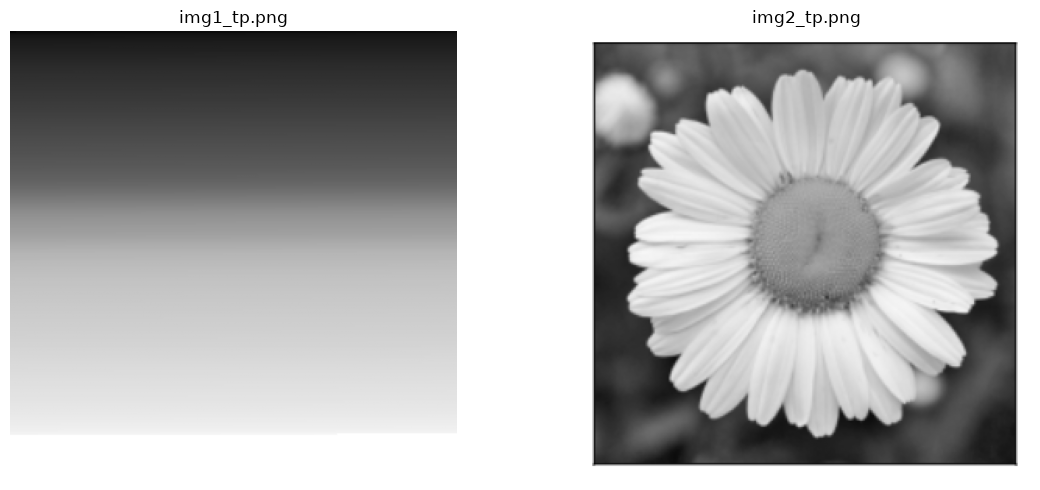

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("img1_tp.png")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("img2_tp.png")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [23]:
num_bins = 256

hist1, bin_edges1 = np.histogram(
    img1.ravel(),
    bins=num_bins,
    range=(0, 256)
)

hist2, bin_edges2 = np.histogram(
    img2.ravel(),
    bins=num_bins,
    range=(0, 256)
)

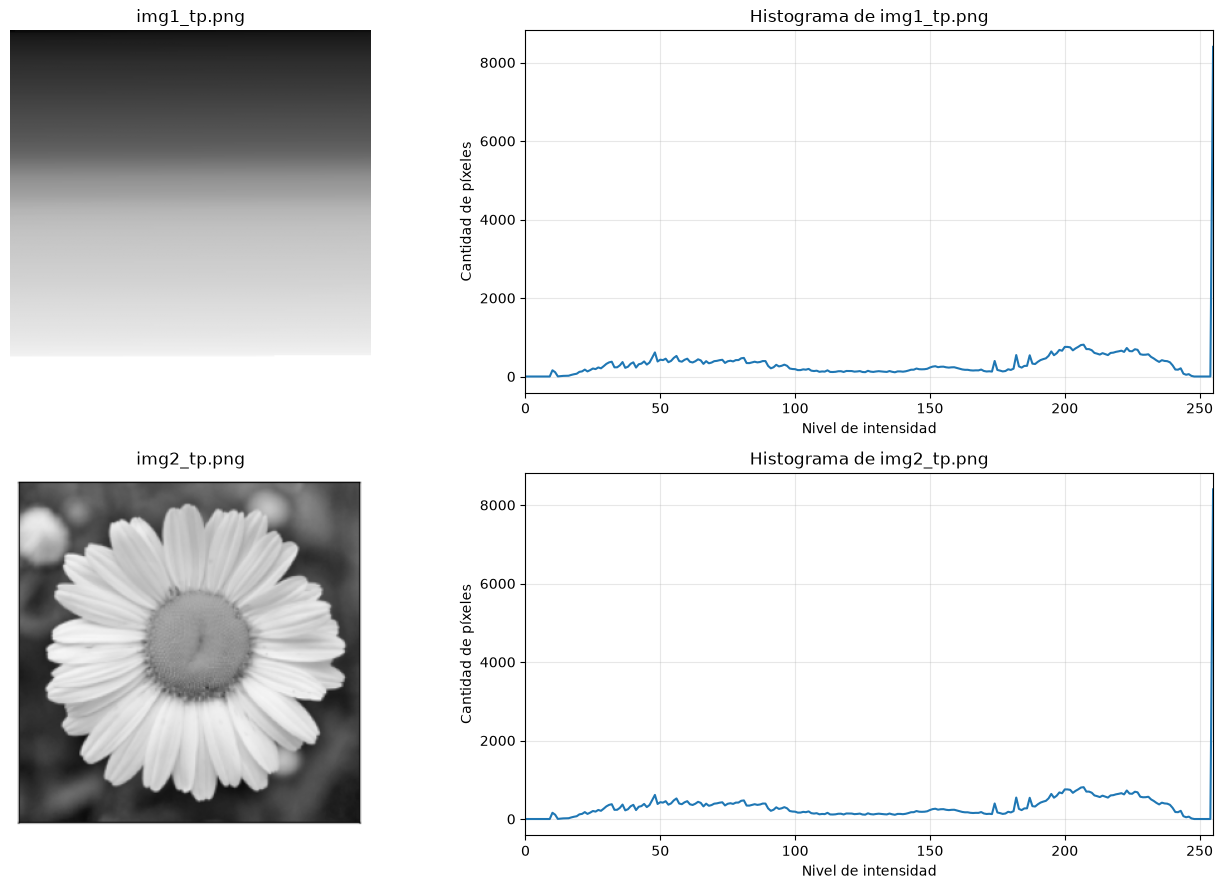

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("img1_tp.png")
axes[0, 0].axis("off")

axes[0, 1].plot(hist1)
axes[0, 1].set_title("Histograma de img1_tp.png")
axes[0, 1].set_xlabel("Nivel de intensidad")
axes[0, 1].set_ylabel("Cantidad de píxeles")
axes[0, 1].set_xlim(0, 255)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("img2_tp.png")
axes[1, 0].axis("off")

axes[1, 1].plot(hist2)
axes[1, 1].set_title("Histograma de img2_tp.png")
axes[1, 1].set_xlabel("Nivel de intensidad")
axes[1, 1].set_ylabel("Cantidad de píxeles")
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

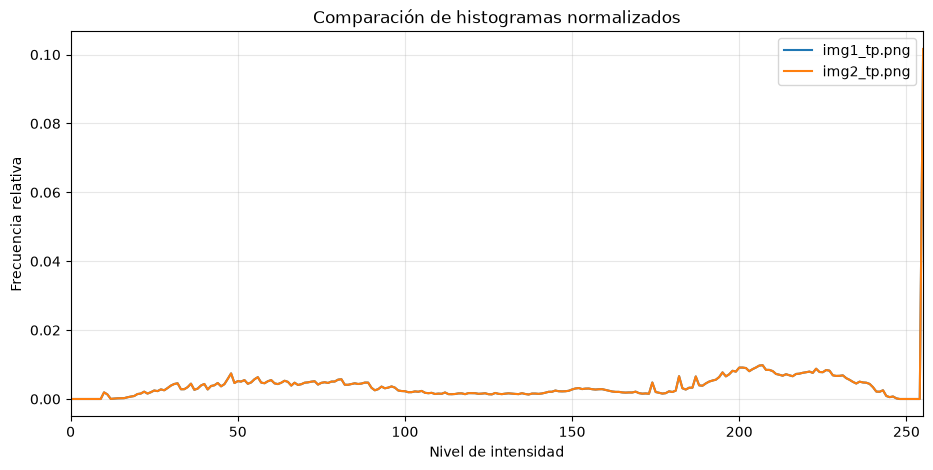

In [25]:
hist1_norm = hist1 / hist1.sum()
hist2_norm = hist2 / hist2.sum()

plt.figure(figsize=(11, 5))

plt.plot(hist1_norm, label="img1_tp.png")
plt.plot(hist2_norm, label="img2_tp.png")

plt.title("Comparación de histogramas normalizados")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia relativa")
plt.xlim(0, 255)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [26]:
def image_statistics(image):
    return {
        "mínimo": np.min(image),
        "máximo": np.max(image),
        "media": np.mean(image),
        "mediana": np.median(image),
        "desvío estándar": np.std(image)
    }

In [27]:
stats1 = image_statistics(img1)
stats2 = image_statistics(img2)

print("Estadísticas img1_tp.png")
for key, value in stats1.items():
    print(f"{key}: {value:.2f}")

print("\nEstadísticas img2_tp.png")
for key, value in stats2.items():
    print(f"{key}: {value:.2f}")

Estadísticas img1_tp.png
mínimo: 2.00
máximo: 255.00
media: 154.81
mediana: 182.00
desvío estándar: 75.34

Estadísticas img2_tp.png
mínimo: 2.00
máximo: 255.00
media: 154.81
mediana: 182.00
desvío estándar: 75.34


## Análisis de los histogramas

Se utilizaron 256 bins porque las imágenes están representadas en escala de grises de 8 bits. De esta manera, cada bin corresponde a uno de los posibles niveles de intensidad comprendidos entre 0 y 255.

A pesar de que las dos imágenes son visualmente muy diferentes, sus histogramas son prácticamente idénticos. En `img1_tp.png` se observa un gradiente suave, mientras que `img2_tp.png` contiene la imagen de una flor, con bordes, formas y regiones claramente diferenciadas. Sin embargo, ambas presentan la misma distribución global de intensidades.

Esto también se refleja en las estadísticas calculadas. Las dos imágenes tienen un valor mínimo de 2, un máximo de 255, una media de 154,81, una mediana de 182 y un desvío estándar de 75,34. Además, poseen las mismas dimensiones, por lo que la igualdad de los histogramas no se debe a una normalización entre imágenes de distinto tamaño.

La distribución presenta una cantidad importante de píxeles en intensidades altas, especialmente en el valor 255, y otros grupos de intensidades alrededor de los niveles medios y medio-altos. No obstante, esta información no permite distinguir entre las dos imágenes, ya que el histograma solamente contabiliza cuántos píxeles existen de cada intensidad y no indica dónde se encuentran.

Este resultado muestra con claridad la principal limitación de utilizar histogramas globales como features. Un histograma puede representar características generales como brillo, contraste o distribución tonal, pero pierde por completo la información espacial. En este caso, los mismos niveles de gris fueron organizados de manera diferente: en una imagen forman un gradiente y en la otra representan una flor.

Por lo tanto, los histogramas podrían ser útiles como features complementarias en un modelo de clasificación cuando las clases presentan diferencias globales de iluminación o contraste. Sin embargo, no serían suficientes por sí solos para distinguir imágenes cuya diferencia depende de la forma, la textura o la disposición espacial de los píxeles.

Para una tarea de detección su utilidad sería todavía más limitada, ya que no permiten determinar la posición de los objetos dentro de la imagen. En ese caso sería necesario utilizar características que conserven información espacial, como bordes, texturas, histogramas calculados por regiones o features obtenidas mediante redes convolucionales.

En conclusión, este ejemplo demuestra que dos imágenes completamente distintas pueden tener exactamente el mismo histograma. Por ese motivo, los histogramas globales pueden aportar información útil sobre la distribución de intensidades, pero deben combinarse con otros descriptores si se busca representar adecuadamente el contenido visual de una imagen.